# Lección 5 - Ecuaciones en Derivadas Parciales

**Ampliación de Matemáticas - GIERM**

---

## Objetivos de aprendizaje

- Comprender la clasificación de las tres EDPs fundamentales: onda, calor y Laplace
- Resolver problemas de valores propios de Sturm-Liouville con distintas condiciones de contorno
- Aplicar separación de variables a la ecuación de onda y obtener la solución de Bernoulli
- Resolver la ecuación de calor y entender la diferencia con la de onda (decaimiento vs. oscilación)
- Manejar condiciones de contorno no homogéneas mediante descomposición en estado estacionario
- Conocer la fórmula de D'Alembert para la ecuación de onda

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'   # azul - curvas principales
COLOR_RECTA = '#cb181d'       # rojo - límites, destacados
COLOR_PUNTO = '#238b45'       # verde - resultados, puntos clave
COLOR_SEC1 = '#6baed6'        # azul claro
COLOR_SEC2 = '#fd8d3c'        # naranja
COLOR_SEC3 = '#74c476'        # verde claro
COLOR_SEC4 = '#9e9ac8'        # violeta

print('Configuración lista.')

Configuración lista.


---

## 1. Introducción a las Ecuaciones en Derivadas Parciales

Una **ecuación en derivadas parciales (EDP)** es una ecuación diferencial que involucra una función de **varias variables independientes** y sus derivadas parciales. A diferencia de las EDOs (una sola variable independiente), las EDPs modelan fenómenos que dependen del **espacio** y del **tiempo** simultáneamente.

### Variables y condiciones

- **Variables independientes**: típicamente $x$ (espacio) y $t$ (tiempo)
- **Condiciones de contorno (CC)**: impuestas en los extremos espaciales del dominio ($x = 0$, $x = L$)
- **Condiciones iniciales (CI)**: impuestas en $t = 0$ (estado del sistema al inicio)

### Las tres EDPs fundamentales

| EDP | Ecuación | Fenómeno | Comportamiento |
|-----|----------|----------|----------------|
| **Ecuación de onda** | $u_{tt} = c^2 \, u_{xx}$ | Cuerda vibrante, sonido | Oscilación periódica |
| **Ecuación de calor** | $u_t = \kappa \, u_{xx}$ | Difusión térmica | Decaimiento exponencial |
| **Ecuación de Laplace** | $u_{xx} + u_{yy} = 0$ | Estado estacionario, electrostática | Equilibrio (sin evolución temporal) |

**Clave**: la ecuación de onda tiene derivada **segunda** en $t$ (oscilación), la de calor tiene derivada **primera** en $t$ (decaimiento irreversible).

### Método general: Separación de variables

El método consiste en proponer $u(x,t) = v(x) \cdot z(t)$ y sustituir en la EDP. Esto genera:
1. Un **problema de valores propios** en $x$ (ecuación de Sturm-Liouville) $\to$ determina las autofunciones
2. Una **EDO** en $t$ $\to$ se resuelve una vez conocidos los valores propios

---

## 2. Problemas de valores propios (Sturm-Liouville)

El problema fundamental que aparece en la separación de variables es:

$$\boxed{v''(x) + \lambda \, v(x) = 0, \qquad 0 \le x \le L}$$

con distintas **condiciones de contorno**. Los valores de $\lambda$ para los que existe solución no trivial se llaman **valores propios** y las soluciones correspondientes son las **autofunciones** (o funciones propias).

### 2.1 Condiciones de Dirichlet: $v(0) = 0$, $v(L) = 0$

$$\boxed{\lambda_n = \frac{n^2 \pi^2}{L^2}, \qquad v_n(x) = \sin\!\left(\frac{n\pi x}{L}\right), \quad n = 1, 2, 3, \ldots}$$

### 2.2 Condiciones de Neumann: $v'(0) = 0$, $v'(L) = 0$

$$\boxed{\lambda_n = \frac{n^2 \pi^2}{L^2}, \qquad v_n(x) = \cos\!\left(\frac{n\pi x}{L}\right), \quad n = 0, 1, 2, \ldots}$$

**Nota**: el caso $n=0$ ($\lambda_0 = 0$, $v_0 = 1$) es válido.

### 2.3 Mixtas tipo I: $v(0) = 0$, $v'(L) = 0$

$$\boxed{\lambda_n = \frac{(2n+1)^2 \pi^2}{4L^2}, \qquad v_n(x) = \sin\!\left(\frac{(2n+1)\pi x}{2L}\right), \quad n = 0, 1, 2, \ldots}$$

### 2.4 Mixtas tipo II: $v'(0) = 0$, $v(L) = 0$

$$\boxed{\lambda_n = \frac{(2n+1)^2 \pi^2}{4L^2}, \qquad v_n(x) = \cos\!\left(\frac{(2n+1)\pi x}{2L}\right), \quad n = 0, 1, 2, \ldots}$$

### 2.5 Condiciones periódicas: $v(0) = v(L)$, $v'(0) = v'(L)$

$$\lambda_n = \frac{4n^2\pi^2}{L^2}, \quad v_n(x) = \left\{\cos\!\left(\frac{2n\pi x}{L}\right),\; \sin\!\left(\frac{2n\pi x}{L}\right)\right\}, \quad n = 0, 1, 2, \ldots$$

Cada valor propio ($n \ge 1$) tiene **multiplicidad 2** (seno y coseno).

### Tabla resumen

| Tipo CC | $\lambda_n$ | $v_n(x)$ | $n$ empieza en |
|---------|-------------|-----------|-----------------|
| Dirichlet-Dirichlet | $\dfrac{n^2\pi^2}{L^2}$ | $\sin(n\pi x/L)$ | $n=1$ |
| Neumann-Neumann | $\dfrac{n^2\pi^2}{L^2}$ | $\cos(n\pi x/L)$ | $n=0$ |
| Dirichlet-Neumann | $\dfrac{(2n+1)^2\pi^2}{4L^2}$ | $\sin((2n+1)\pi x/(2L))$ | $n=0$ |
| Neumann-Dirichlet | $\dfrac{(2n+1)^2\pi^2}{4L^2}$ | $\cos((2n+1)\pi x/(2L))$ | $n=0$ |

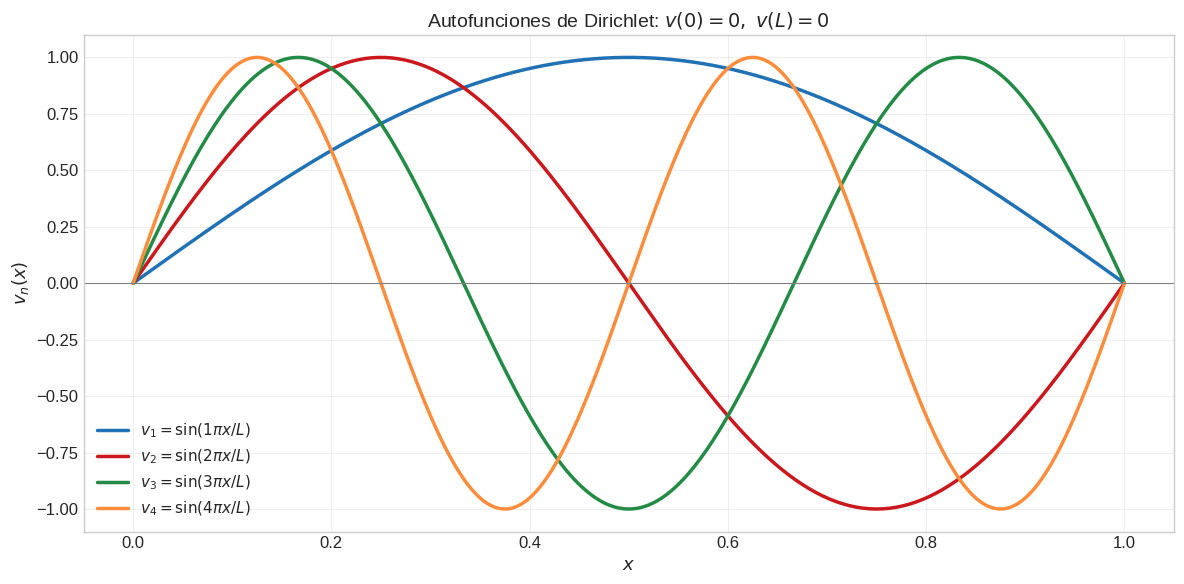

In [2]:
# Primeras 4 autofunciones de Dirichlet
L = 1.0
x = np.linspace(0, L, 300)
colores = [COLOR_PRINCIPAL, COLOR_RECTA, COLOR_PUNTO, COLOR_SEC2]

fig, ax = plt.subplots(figsize=(12, 6))

for n, col in zip(range(1, 5), colores):
    v_n = np.sin(n * np.pi * x / L)
    ax.plot(x, v_n, color=col, lw=2.5, label=r'$v_%d = \sin(%d\pi x/L)$' % (n, n))

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$v_n(x)$')
ax.set_title(r'Autofunciones de Dirichlet: $v(0)=0,\; v(L)=0$')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', lw=0.8)
plt.tight_layout()
plt.show()

---

## 3. Ecuación de onda

### 3.1 Planteamiento

La ecuación de onda modela la vibración de una cuerda tensa de longitud $L$:

$$\boxed{u_{tt} = c^2 \, u_{xx}, \qquad 0 \le x \le L, \quad t \ge 0}$$

donde $c > 0$ es la **velocidad de propagación** de la onda.

**Condiciones de contorno** (extremos fijos):

$$u(0,t) = 0, \qquad u(L,t) = 0 \quad \forall t \ge 0$$

**Condiciones iniciales**:

$$u(x,0) = f(x) \quad \text{(desplazamiento inicial)}, \qquad u_t(x,0) = g(x) \quad \text{(velocidad inicial)}$$

### 3.2 Separación de variables

Se propone $u(x,t) = v(x) \cdot z(t)$. Sustituyendo en la EDP:

$$v(x) \, z''(t) = c^2 \, v''(x) \, z(t) \implies \frac{z''(t)}{c^2 \, z(t)} = \frac{v''(x)}{v(x)} = -\lambda$$

Esto genera **dos EDOs**:

$$v''(x) + \lambda \, v(x) = 0 \quad \text{(Sturm-Liouville)}$$

$$z''(t) + \lambda \, c^2 \, z(t) = 0 \quad \text{(oscilador armónico)}$$

Con CC de Dirichlet: $\lambda_n = n^2\pi^2/L^2$, $v_n = \sin(n\pi x/L)$.

La EDO temporal: $z_n'' + (n\pi c/L)^2 z_n = 0$ $\implies$ $z_n(t) = a_n \sin(n\pi ct/L) + b_n \cos(n\pi ct/L)$.

### 3.3 Solución de Bernoulli

$$\boxed{u(x,t) = \sum_{n=1}^{\infty} \sin\!\left(\frac{n\pi x}{L}\right)\left[a_n \sin\!\left(\frac{n\pi ct}{L}\right) + b_n \cos\!\left(\frac{n\pi ct}{L}\right)\right]}$$

Donde los coeficientes se determinan por las condiciones iniciales:

$$\boxed{b_n = \frac{2}{L} \int_0^L f(x) \sin\!\left(\frac{n\pi x}{L}\right) dx} \qquad \text{(coeficientes de Fourier seno de } f \text{)}$$

$$\boxed{a_n = \frac{2}{n\pi c} \int_0^L g(x) \sin\!\left(\frac{n\pi x}{L}\right) dx}$$

### 3.4 Caso especial: $g(x) = 0$ (sin velocidad inicial)

$$u(x,t) = \sum_{n=1}^{\infty} b_n \sin\!\left(\frac{n\pi x}{L}\right) \cos\!\left(\frac{n\pi ct}{L}\right)$$

### 3.5 Solución de D'Alembert

Forma alternativa para la ecuación de onda en dominio infinito o extensiones:

$$\boxed{u(x,t) = \varphi(x + ct) + \psi(x - ct)}$$

donde $\varphi$ y $\psi$ son las **extensiones impares y $2L$-periódicas** de funciones determinadas por $f$ y $g$:
- Si $g = 0$: $\varphi(s) = \psi(s) = \tilde{f}(s)/2$ donde $\tilde{f}$ es la extensión impar $2L$-periódica de $f$
- $u(x,t) = \frac{1}{2}[\tilde{f}(x+ct) + \tilde{f}(x-ct)]$

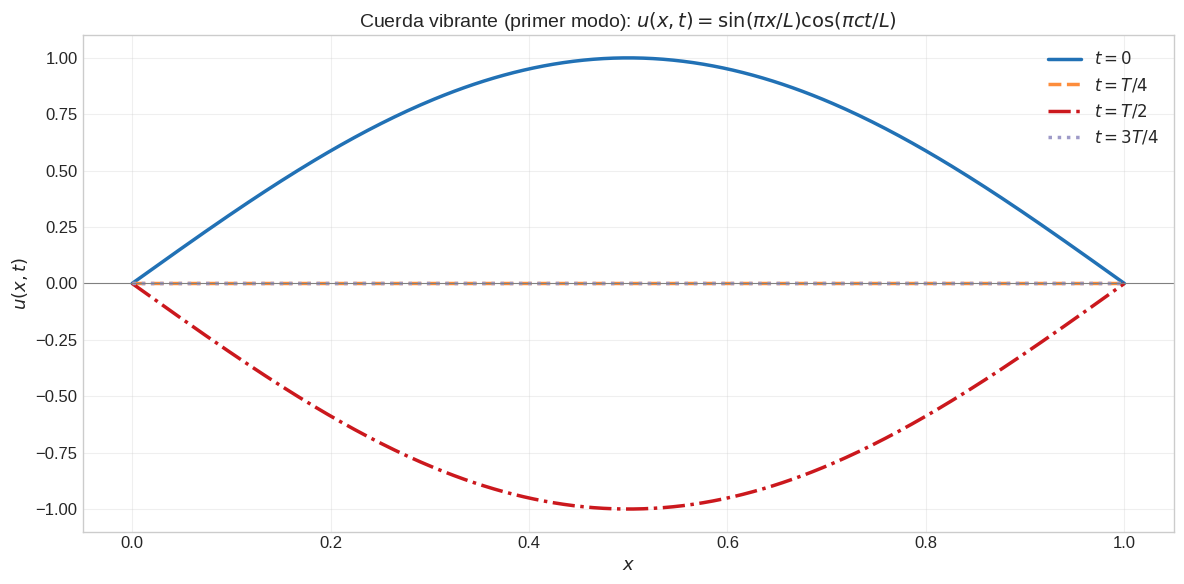

In [3]:
# Cuerda vibrante en distintos instantes
L = 1.0
c = 1.0
T = 2 * L / c  # Periodo fundamental
x = np.linspace(0, L, 300)

# Condición inicial: f(x) = sin(pi*x/L), g=0 (primer modo)
# Solución exacta: u(x,t) = sin(pi*x/L) * cos(pi*c*t/L)

tiempos = [0, T/4, T/2, 3*T/4]
etiquetas = [r'$t = 0$', r'$t = T/4$', r'$t = T/2$', r'$t = 3T/4$']
colores = [COLOR_PRINCIPAL, COLOR_SEC2, COLOR_RECTA, COLOR_SEC4]
estilos = ['-', '--', '-.', ':']

fig, ax = plt.subplots(figsize=(12, 6))

for t_val, etiq, col, ls in zip(tiempos, etiquetas, colores, estilos):
    u = np.sin(np.pi * x / L) * np.cos(np.pi * c * t_val / L)
    ax.plot(x, u, color=col, lw=2.5, ls=ls, label=etiq)

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$u(x,t)$')
ax.set_title(r'Cuerda vibrante (primer modo): $u(x,t) = \sin(\pi x/L)\cos(\pi ct/L)$')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', lw=0.8)
plt.tight_layout()
plt.show()

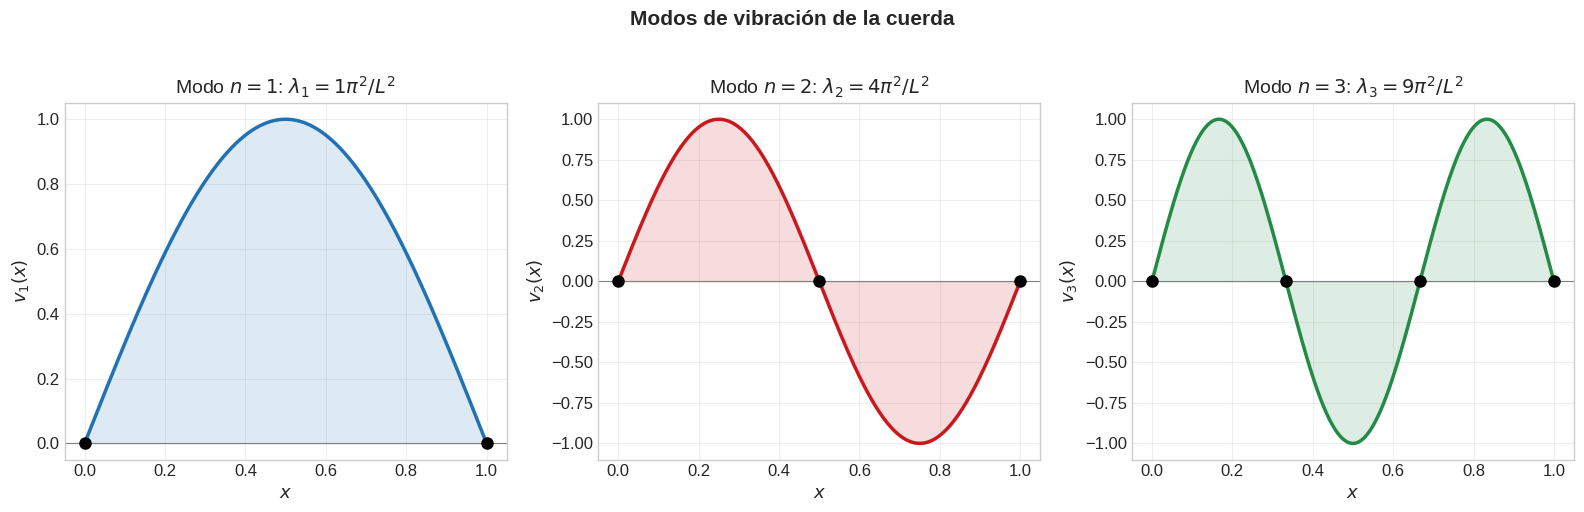

In [4]:
# Primeros 3 modos de vibración
L = 1.0
x = np.linspace(0, L, 300)
colores_modos = [COLOR_PRINCIPAL, COLOR_RECTA, COLOR_PUNTO]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, n in enumerate([1, 2, 3]):
    ax = axes[idx]
    v_n = np.sin(n * np.pi * x / L)
    ax.plot(x, v_n, color=colores_modos[idx], lw=2.5)
    ax.fill_between(x, v_n, alpha=0.15, color=colores_modos[idx])
    ax.set_title(r'Modo $n=%d$: $\lambda_%d = %d\pi^2/L^2$' % (n, n, n**2))
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$v_%d(x)$' % n)
    ax.axhline(y=0, color='gray', lw=0.8)
    ax.grid(True, alpha=0.3)
    # Marcar nodos
    for k in range(n + 1):
        ax.plot(k / n * L, 0, 'o', color='black', ms=8, zorder=5)

fig.suptitle('Modos de vibración de la cuerda', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 4. Ecuación de calor

### 4.1 Planteamiento

La ecuación de calor modela la difusión térmica en una barra de longitud $L$:

$$\boxed{u_t = \kappa \, u_{xx}, \qquad 0 \le x \le L, \quad t \ge 0}$$

donde $\kappa > 0$ es la **difusividad térmica**.

**Condiciones de contorno** (extremos a temperatura cero):

$$u(0,t) = 0, \qquad u(L,t) = 0 \quad \forall t \ge 0$$

**Condición inicial**: $u(x,0) = f(x)$.

### 4.2 Separación de variables

Con $u(x,t) = v(x) \cdot z(t)$:

$$v(x) \, z'(t) = \kappa \, v''(x) \, z(t) \implies \frac{z'(t)}{\kappa \, z(t)} = \frac{v''(x)}{v(x)} = -\lambda$$

**Problema espacial** (Sturm-Liouville): $v'' + \lambda v = 0$ con Dirichlet $\to$ $\lambda_n = n^2\pi^2/L^2$, $v_n = \sin(n\pi x/L)$.

**Problema temporal**: $z'(t) + \lambda_n \kappa \, z(t) = 0$ $\implies$ $z_n(t) = e^{-n^2\pi^2\kappa t/L^2}$.

### 4.3 Solución

$$\boxed{u(x,t) = \sum_{n=1}^{\infty} b_n \sin\!\left(\frac{n\pi x}{L}\right) e^{-n^2\pi^2\kappa t/L^2}}$$

$$\boxed{b_n = \frac{2}{L} \int_0^L f(x) \sin\!\left(\frac{n\pi x}{L}\right) dx}$$

### 4.4 Diferencia fundamental: calor vs. onda

| Aspecto | Ecuación de onda | Ecuación de calor |
|---------|------------------|-------------------|
| Derivada en $t$ | $u_{tt}$ (segunda) | $u_t$ (primera) |
| Factor temporal | $\sin, \cos$ $\to$ **oscilación** | $e^{-\alpha t}$ $\to$ **decaimiento** |
| Largo plazo | Vibra indefinidamente | Tiende a **estado estacionario** |
| Reversibilidad | Reversible en $t$ | **Irreversible** |

### 4.5 Estado estacionario ($t \to \infty$)

- Con CC homogéneas ($u(0,t)=u(L,t)=0$): $u \to 0$ (toda la barra a temperatura cero)
- Con CC no homogéneas ($u(0,t)=T_1$, $u(L,t)=T_2$): $u \to v(x) = T_1 + \frac{T_2 - T_1}{L} x$ (perfil lineal)

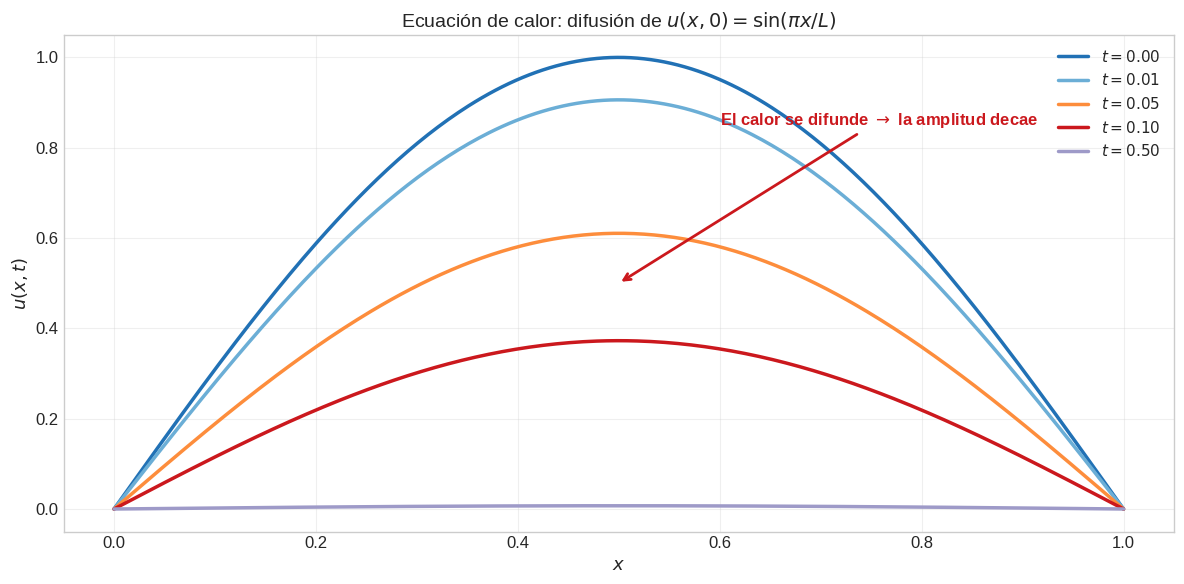

In [5]:
# Distribución de temperatura en distintos instantes
L = 1.0
kappa = 1.0
x = np.linspace(0, L, 300)
N_terms = 50  # Términos de la serie

# Condición inicial: f(x) = sin(pi*x/L) (primer modo, b_1=1, resto 0)
# Solución exacta: u(x,t) = sin(pi*x/L) * exp(-pi^2*kappa*t/L^2)

tiempos = [0, 0.01, 0.05, 0.1, 0.5]
colores_t = [COLOR_PRINCIPAL, COLOR_SEC1, COLOR_SEC2, COLOR_RECTA, COLOR_SEC4]

fig, ax = plt.subplots(figsize=(12, 6))

for t_val, col in zip(tiempos, colores_t):
    u = np.sin(np.pi * x / L) * np.exp(-np.pi**2 * kappa * t_val / L**2)
    ax.plot(x, u, color=col, lw=2.5, label=r'$t = %.2f$' % t_val)

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$u(x,t)$')
ax.set_title(r'Ecuación de calor: difusión de $u(x,0) = \sin(\pi x/L)$')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.annotate(r'El calor se difunde $\to$ la amplitud decae',
            xy=(0.5, 0.5), xytext=(0.6, 0.85),
            fontsize=12, color=COLOR_RECTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=2))
plt.tight_layout()
plt.show()

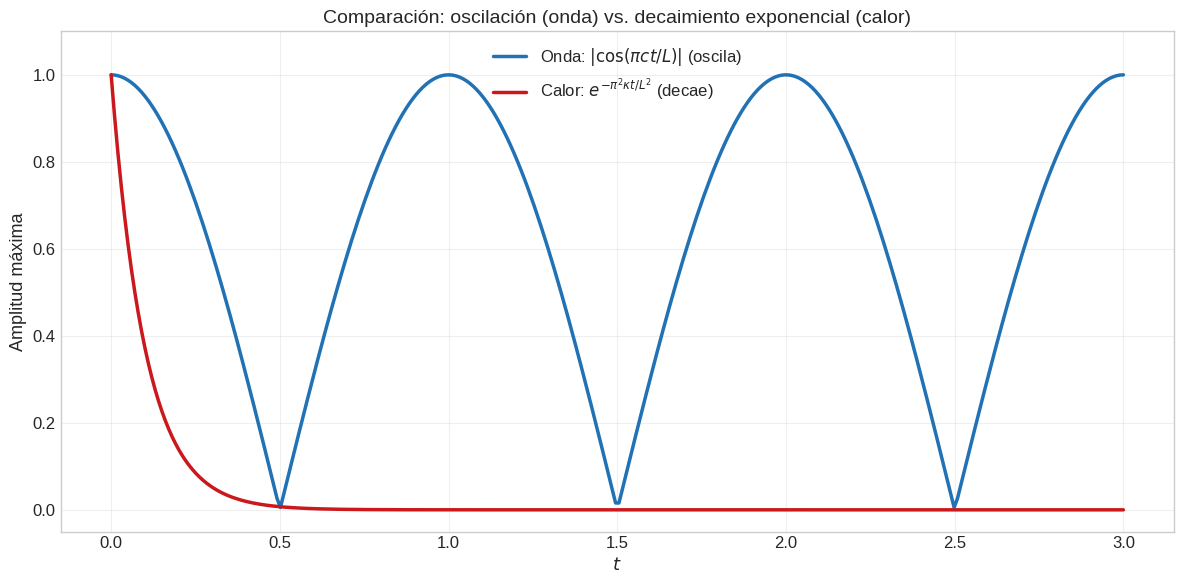

In [6]:
# Comparación: onda vs calor (evolución temporal del máximo)
L = 1.0
c = 1.0
kappa = 1.0
t = np.linspace(0, 3, 300)

# Amplitud máxima del primer modo
amp_onda = np.abs(np.cos(np.pi * c * t / L))  # |cos(pi*c*t/L)|
amp_calor = np.exp(-np.pi**2 * kappa * t / L**2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t, amp_onda, color=COLOR_PRINCIPAL, lw=2.5, label=r'Onda: $|\cos(\pi ct/L)|$ (oscila)')
ax.plot(t, amp_calor, color=COLOR_RECTA, lw=2.5, label=r'Calor: $e^{-\pi^2\kappa t/L^2}$ (decae)')

ax.set_xlabel(r'$t$')
ax.set_ylabel(r'Amplitud máxima')
ax.set_title('Comparación: oscilación (onda) vs. decaimiento exponencial (calor)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()

---

## 5. Ecuación de calor con condiciones de contorno no homogéneas

### Planteamiento

$$u_t = \kappa \, u_{xx}, \qquad u(0,t) = T_1, \quad u(L,t) = T_2, \quad u(x,0) = f(x)$$

Las CC no son cero, así que **no se puede aplicar directamente** la separación de variables.

### Método: descomposición en estado estacionario + transitorio

Se escribe $u(x,t) = v(x) + w(x,t)$ donde:

**1. Estado estacionario** $v(x)$: satisface $v'' = 0$ con $v(0) = T_1$, $v(L) = T_2$.

$$\boxed{v(x) = T_1 + \frac{T_2 - T_1}{L} \, x}$$

**2. Transitorio** $w(x,t) = u(x,t) - v(x)$: satisface la ecuación de calor con CC **homogéneas**:

$$w_t = \kappa \, w_{xx}, \qquad w(0,t) = 0, \quad w(L,t) = 0$$

$$w(x,0) = f(x) - v(x) \quad \text{(condición inicial modificada)}$$

**3. Solución del transitorio** (serie de Fourier seno):

$$w(x,t) = \sum_{n=1}^{\infty} b_n \sin\!\left(\frac{n\pi x}{L}\right) e^{-n^2\pi^2\kappa t/L^2}$$

$$b_n = \frac{2}{L} \int_0^L \left[f(x) - v(x)\right] \sin\!\left(\frac{n\pi x}{L}\right) dx$$

**4. Solución completa:**

$$\boxed{u(x,t) = T_1 + \frac{T_2 - T_1}{L}x + \sum_{n=1}^{\infty} b_n \sin\!\left(\frac{n\pi x}{L}\right) e^{-n^2\pi^2\kappa t/L^2}}$$

**Error frecuente**: olvidar restar $v(x)$ de la condición inicial al calcular $b_n$.

---

## 6. Ejercicios resueltos

### 6.1 Ecuación de onda: desplazamiento inicial triangular

#### Ejercicio resuelto: Onda con $f(x) = x(L-x)$, $g = 0$

**Datos:** $u_{tt} = c^2 u_{xx}$, $0 \le x \le L$, $u(0,t) = u(L,t) = 0$, $u(x,0) = x(L-x)$, $u_t(x,0) = 0$.

**Paso 1:** Como $g = 0$, tenemos $a_n = 0$ para todo $n$. La solución es:

$$u(x,t) = \sum_{n=1}^{\infty} b_n \sin\!\left(\frac{n\pi x}{L}\right) \cos\!\left(\frac{n\pi ct}{L}\right)$$

**Paso 2:** Calcular $b_n$:

$$b_n = \frac{2}{L} \int_0^L x(L-x) \sin\!\left(\frac{n\pi x}{L}\right) dx$$

Integrando por partes dos veces (o usando la tabla de integrales):

$$b_n = \frac{2}{L} \cdot \frac{4L^3}{n^3\pi^3} \cdot \frac{1 - (-1)^n}{2} = \begin{cases} \dfrac{8L^2}{n^3\pi^3} & \text{si } n \text{ impar} \\[6pt] 0 & \text{si } n \text{ par} \end{cases}$$

**Paso 3:** Solución final:

$$\boxed{u(x,t) = \frac{8L^2}{\pi^3} \sum_{k=0}^{\infty} \frac{1}{(2k+1)^3} \sin\!\left(\frac{(2k+1)\pi x}{L}\right) \cos\!\left(\frac{(2k+1)\pi ct}{L}\right)}$$

**Observación:** los coeficientes decaen como $1/n^3$, por lo que la serie converge rápidamente.

### 6.2 Ecuación de onda: velocidad inicial

#### Ejercicio resuelto: Onda con $f = 0$, $g(x) = 1$

**Datos:** $u_{tt} = c^2 u_{xx}$, $0 \le x \le L$, $u(0,t) = u(L,t) = 0$, $u(x,0) = 0$, $u_t(x,0) = 1$.

**Paso 1:** Como $f = 0$, tenemos $b_n = 0$ para todo $n$. La solución es:

$$u(x,t) = \sum_{n=1}^{\infty} a_n \sin\!\left(\frac{n\pi x}{L}\right) \sin\!\left(\frac{n\pi ct}{L}\right)$$

**Paso 2:** Calcular $a_n$:

$$a_n = \frac{2}{n\pi c} \int_0^L 1 \cdot \sin\!\left(\frac{n\pi x}{L}\right) dx = \frac{2}{n\pi c} \cdot \frac{L}{n\pi}[1 - (-1)^n]$$

$$a_n = \begin{cases} \dfrac{4L}{n^2\pi^2 c} & \text{si } n \text{ impar} \\[6pt] 0 & \text{si } n \text{ par} \end{cases}$$

**Paso 3:** Solución final:

$$\boxed{u(x,t) = \frac{4L}{\pi^2 c} \sum_{k=0}^{\infty} \frac{1}{(2k+1)^2} \sin\!\left(\frac{(2k+1)\pi x}{L}\right) \sin\!\left(\frac{(2k+1)\pi ct}{L}\right)}$$

### 6.3 Solución de D'Alembert

#### Ejercicio resuelto: $u_{tt} = 4u_{xx}$, $L=2$, $f(x) = x(2-x)$, $g=0$

**Datos:** $c^2 = 4$ $\implies$ $c = 2$, $L = 2$, $u(0,t) = u(2,t) = 0$, $f(x) = x(2-x)$, $g = 0$.

**Paso 1:** Con D'Alembert y $g = 0$:

$$u(x,t) = \frac{1}{2}[\tilde{f}(x + 2t) + \tilde{f}(x - 2t)]$$

donde $\tilde{f}$ es la extensión impar $4$-periódica de $f$.

**Paso 2:** La extensión impar ($2L = 4$-periódica):
- En $[0, 2]$: $\tilde{f}(s) = s(2-s)$
- En $[-2, 0]$: $\tilde{f}(s) = -(-s)(2-(-s)) = s(2+s)$
- Periódica con periodo $4$

**Paso 3:** Evaluar en $t = 3/4$:
- $x + ct = x + 3/2$
- $x - ct = x - 3/2$

Para $x \in [0, 2]$:
- $x + 3/2 \in [3/2, 7/2]$: reducir módulo 4 y aplicar extensión impar
- $x - 3/2 \in [-3/2, 1/2]$: usar extensión impar

**Paso 4:** Evaluar en $t = 1$:
- $x + 2 \in [2, 4]$: $\tilde{f}(x+2) = -\tilde{f}(4-(x+2)) = -(2-x)(x) = -x(2-x)$

  (ya que $\tilde{f}$ es impar y $4$-periódica, $\tilde{f}(s+4) = \tilde{f}(s)$ y $\tilde{f}(4-s) = \tilde{f}(-s) = -\tilde{f}(s)$)

- $x - 2 \in [-2, 0]$: $\tilde{f}(x-2) = -(2-x)(x) = -x(2-x)$

$$u(x,1) = \frac{1}{2}[-x(2-x) + (-x(2-x))] = -x(2-x)$$

$$\boxed{u(x,1) = -x(2-x)}$$

**Interpretación:** en $t = 1 = T/2$, la cuerda ha completado medio periodo y está invertida respecto a la posición inicial.

### 6.4 Ecuación de calor directa

#### Ejercicio resuelto: $u_t = u_{xx}$, $u(0,t) = u(\pi,t) = 0$, $u(x,0) = \sin(x) + 3\sin(2x)$

**Datos:** $\kappa = 1$, $L = \pi$.

**Paso 1:** La condición inicial ya está en la base de autofunciones $\{\sin(nx)\}$:

$$u(x,0) = 1 \cdot \sin(x) + 3 \cdot \sin(2x)$$

Luego $b_1 = 1$, $b_2 = 3$, $b_n = 0$ para $n \ge 3$.

**Paso 2:** Con $L = \pi$, $\kappa = 1$: $\lambda_n = n^2$, y la solución es:

$$u(x,t) = \sum_{n=1}^{\infty} b_n \sin(nx) \, e^{-n^2 t}$$

**Paso 3:** Solución:

$$\boxed{u(x,t) = \sin(x) \, e^{-t} + 3\sin(2x) \, e^{-4t}}$$

**Observación:** el segundo modo ($n=2$) decae **4 veces más rápido** que el primero ($e^{-4t}$ vs $e^{-t}$). Los modos altos desaparecen antes $\to$ la distribución se "suaviza".

### 6.5 Calor con condiciones no homogéneas

#### Ejercicio resuelto: $u_t = u_{xx}$, $u(0,t) = 0$, $u(1,t) = 100$, $u(x,0) = 50x$

**Datos:** $\kappa = 1$, $L = 1$, $T_1 = 0$, $T_2 = 100$.

**Paso 1:** Estado estacionario:

$$v(x) = T_1 + \frac{T_2 - T_1}{L} x = 100x$$

**Paso 2:** Condición inicial modificada:

$$w(x,0) = f(x) - v(x) = 50x - 100x = -50x$$

**Paso 3:** Coeficientes $b_n$ del transitorio:

$$b_n = \frac{2}{1} \int_0^1 (-50x) \sin(n\pi x) \, dx = -100 \int_0^1 x \sin(n\pi x) \, dx$$

Integrando por partes:

$$\int_0^1 x \sin(n\pi x) \, dx = \left[-\frac{x \cos(n\pi x)}{n\pi}\right]_0^1 + \frac{1}{n\pi}\int_0^1 \cos(n\pi x) \, dx = -\frac{\cos(n\pi)}{n\pi} = \frac{(-1)^{n+1}}{n\pi}$$

$$b_n = -100 \cdot \frac{(-1)^{n+1}}{n\pi} = \frac{100(-1)^n}{n\pi}$$

**Paso 4:** Solución completa:

$$\boxed{u(x,t) = 100x + \frac{100}{\pi} \sum_{n=1}^{\infty} \frac{(-1)^n}{n} \sin(n\pi x) \, e^{-n^2\pi^2 t}}$$

**Verificación:** en $t \to \infty$, $u(x,\infty) = 100x = v(x)$ (estado estacionario lineal). En $t = 0$, $u(x,0) = 100x + \frac{100}{\pi}\sum \frac{(-1)^n}{n}\sin(n\pi x) = 100x - 50x = 50x$ $\checkmark$

---

## 7. Catálogo completo de ejercicios: todos los patrones

### Tabla resumen

| # | Tipo | Ecuación clave | Método |
|---|------|----------------|--------|
| 1 | Problema de valores propios | $v'' + \lambda v = 0$ + CC | Sturm-Liouville |
| 2 | Onda con $g = 0$ | $u = \sum b_n \sin \cos$ | Series de Fourier seno de $f$ |
| 3 | Onda con $f = 0$ | $u = \sum a_n \sin \sin$ | Integrar $g$ para $a_n$ |
| 4 | Onda con $f$ y $g$ | Solución completa Bernoulli | Ambos conjuntos de coeficientes |
| 5 | D'Alembert | $u = \varphi(x+ct) + \psi(x-ct)$ | Extensión impar periódica |
| 6 | Calor con Dirichlet homogéneo | $u = \sum b_n \sin \cdot e^{-\alpha t}$ | Series seno + decaimiento |
| 7 | Calor con Neumann | $u = \sum b_n \cos \cdot e^{-\alpha t}$ | Series coseno + decaimiento |
| 8 | Calor con CC no homogéneas | $u = v(x) + w(x,t)$ | Descomposición estacionario |
| 9 | Estado estacionario | $u_{xx} = 0$ $\to$ $u = ax + b$ | EDO segundo orden |
| 10 | Identificar tipo de EDP | Clasificar por derivadas | Orden de $\partial_t$ |

### 7.1 Tipo 1: Problema de valores propios

Dado $v'' + \lambda v = 0$ con condiciones de contorno, encontrar $\lambda_n$ y $v_n(x)$.

$$\boxed{v(x) = A\cos(\sqrt{\lambda}\,x) + B\sin(\sqrt{\lambda}\,x) \quad (\text{para } \lambda > 0)}$$

**Metodología:**
1. Escribir la solución general (considerar $\lambda > 0$, $\lambda = 0$, $\lambda < 0$)
2. Aplicar la primera CC $\to$ eliminar una constante
3. Aplicar la segunda CC $\to$ obtener la ecuación para $\lambda$
4. Los valores de $\lambda$ que dan solución no trivial son los **valores propios**

**Insight clave:** solo $\lambda > 0$ da solución no trivial para CC de Dirichlet y Neumann. Para CC periódicas, $\lambda = 0$ también es válido.

#### Ejercicio resuelto: $v'' + \lambda v = 0$, $v(0) = 0$, $v(3) = 0$

**Paso 1:** Solución general ($\lambda > 0$): $v = A\cos(\sqrt{\lambda}x) + B\sin(\sqrt{\lambda}x)$

**Paso 2:** $v(0) = 0$: $A = 0$ $\implies$ $v = B\sin(\sqrt{\lambda}x)$

**Paso 3:** $v(3) = 0$: $B\sin(3\sqrt{\lambda}) = 0$. Para $B \ne 0$: $3\sqrt{\lambda} = n\pi$

$$\boxed{\lambda_n = \frac{n^2\pi^2}{9}, \qquad v_n(x) = \sin\!\left(\frac{n\pi x}{3}\right), \quad n = 1, 2, 3, \ldots}$$

### 7.2 Tipo 2: Onda con desplazamiento inicial ($g = 0$)

$$\boxed{u(x,t) = \sum_{n=1}^{\infty} b_n \sin\!\left(\frac{n\pi x}{L}\right) \cos\!\left(\frac{n\pi ct}{L}\right)}$$

$$b_n = \frac{2}{L} \int_0^L f(x) \sin\!\left(\frac{n\pi x}{L}\right) dx$$

**Metodología:**
1. Identificar que $g = 0$ $\implies$ todos los $a_n = 0$
2. Calcular $b_n$ como coeficientes de Fourier seno de $f(x)$
3. Si $f$ ya es una combinación de senos, leer directamente los $b_n$
4. Si no, integrar por partes

**Insight clave:** la solución es $f$ "vibrando" $\to$ cada modo $\sin(n\pi x/L)$ oscila con frecuencia $n\pi c/L$.

#### Ejercicio resuelto: $u_{tt} = 9u_{xx}$, $L=2$, $f(x) = 5\sin(3\pi x/2)$, $g = 0$

**Paso 1:** $c = 3$, $L = 2$. La condición inicial es exactamente $b_3 \cdot \sin(3\pi x/2)$ $\implies$ $b_3 = 5$, resto $b_n = 0$.

**Paso 2:** Solución directa (un solo término):

$$\boxed{u(x,t) = 5\sin\!\left(\frac{3\pi x}{2}\right) \cos\!\left(\frac{9\pi t}{2}\right)}$$

**Truco para el examen:** si $f(x)$ ya es un seno de la forma $\sin(n\pi x/L)$, la solución es inmediata sin calcular integrales.

### 7.3 Tipo 3: Onda con velocidad inicial ($f = 0$)

$$\boxed{u(x,t) = \sum_{n=1}^{\infty} a_n \sin\!\left(\frac{n\pi x}{L}\right) \sin\!\left(\frac{n\pi ct}{L}\right)}$$

$$a_n = \frac{2}{n\pi c} \int_0^L g(x) \sin\!\left(\frac{n\pi x}{L}\right) dx$$

**Metodología:**
1. Identificar que $f = 0$ $\implies$ todos los $b_n = 0$
2. Calcular $a_n$ (ojo: lleva el factor $\frac{2}{n\pi c}$, no $\frac{2}{L}$)
3. El factor temporal es $\sin$ (no $\cos$), porque la cuerda parte de reposo

**Error frecuente:** confundir la fórmula de $a_n$ con la de $b_n$. En $a_n$ aparece $n\pi c$ en el denominador.

#### Ejercicio resuelto: $u_{tt} = 4u_{xx}$, $L=\pi$, $f=0$, $g(x) = \sin(x)$

**Paso 1:** $c = 2$, $L = \pi$. Como $g(x) = \sin(x) = \sin(1 \cdot \pi x / \pi)$ $\to$ $g$ ya es $\sin(n\pi x/L)$ con $n=1$.

**Paso 2:** $a_1 = \frac{2}{1 \cdot \pi \cdot 2} \int_0^{\pi} \sin^2(x) \, dx = \frac{1}{\pi} \cdot \frac{\pi}{2} = \frac{1}{2}$

Resto: $a_n = 0$ para $n \ge 2$.

$$\boxed{u(x,t) = \frac{1}{2} \sin(x) \sin(2t)}$$

### 7.4 Tipo 4: Onda con $f$ y $g$ (caso general)

$$\boxed{u(x,t) = \sum_{n=1}^{\infty} \sin\!\left(\frac{n\pi x}{L}\right)\left[a_n \sin\!\left(\frac{n\pi ct}{L}\right) + b_n \cos\!\left(\frac{n\pi ct}{L}\right)\right]}$$

**Metodología:**
1. Calcular $b_n$ a partir de $f(x)$ (coeficientes de Fourier seno)
2. Calcular $a_n$ a partir de $g(x)$ (con factor $2/(n\pi c)$)
3. Escribir la solución completa

#### Ejercicio resuelto: $u_{tt} = u_{xx}$, $L=1$, $f(x) = \sin(\pi x)$, $g(x) = \sin(2\pi x)$

**Paso 1:** $c = 1$, $L = 1$.

$b_1 = 1$, resto $b_n = 0$ (lectura directa de $f$).

**Paso 2:** $a_2 = \frac{2}{2\pi \cdot 1} \int_0^1 \sin^2(2\pi x) \, dx = \frac{1}{2\pi} \cdot \frac{1}{2} \cdot 2 = \frac{1}{2\pi}$

Resto $a_n = 0$.

**Paso 3:**

$$\boxed{u(x,t) = \sin(\pi x)\cos(\pi t) + \frac{1}{2\pi}\sin(2\pi x)\sin(2\pi t)}$$

### 7.5 Tipo 5: Solución de D'Alembert

$$\boxed{u(x,t) = \frac{1}{2}[\tilde{f}(x+ct) + \tilde{f}(x-ct)] + \frac{1}{2c}\int_{x-ct}^{x+ct} \tilde{g}(s)\,ds}$$

donde $\tilde{f}$ y $\tilde{g}$ son extensiones **impares** y **$2L$-periódicas**.

**Metodología:**
1. Construir la extensión impar de $f$: $\tilde{f}(-x) = -f(x)$
2. Extender con periodo $2L$: $\tilde{f}(x + 2L) = \tilde{f}(x)$
3. Evaluar en los puntos $x \pm ct$, reduciendo al intervalo $[-L, L]$ usando periodicidad
4. Si $g = 0$, usar solo $\frac{1}{2}[\tilde{f}(x+ct) + \tilde{f}(x-ct)]$

**Insight clave:** la extensión impar convierte CC de Dirichlet en periodicidad natural.

#### Ejercicio resuelto: $u_{tt} = u_{xx}$, $L=1$, $f(x) = x(1-x)$, $g = 0$. Hallar $u(1/2, 1)$.

**Paso 1:** $c = 1$, $2L = 2$-periódica impar.

$u(1/2, 1) = \frac{1}{2}[\tilde{f}(3/2) + \tilde{f}(-1/2)]$

**Paso 2:** $\tilde{f}(3/2)$: como $3/2 \in [1,2]$, por periodicidad $\tilde{f}(3/2) = \tilde{f}(3/2 - 2) = \tilde{f}(-1/2) = -f(1/2) = -1/4$

$\tilde{f}(-1/2) = -f(1/2) = -1/4$

**Paso 3:**

$$\boxed{u(1/2, 1) = \frac{1}{2}(-1/4 - 1/4) = -\frac{1}{4}}$$

### 7.6 Tipo 6: Calor con Dirichlet homogéneo

$$\boxed{u(x,t) = \sum_{n=1}^{\infty} b_n \sin\!\left(\frac{n\pi x}{L}\right) e^{-n^2\pi^2\kappa t/L^2}}$$

$$b_n = \frac{2}{L} \int_0^L f(x) \sin\!\left(\frac{n\pi x}{L}\right) dx$$

**Metodología:**
1. Identificar $\kappa$, $L$ de la EDP y las CC
2. Calcular $b_n$ como coeficientes de Fourier seno de $f(x)$
3. Escribir la solución (cada modo decae como $e^{-n^2\pi^2\kappa t/L^2}$)

**Insight clave:** los modos altos ($n$ grande) decaen **mucho más rápido** ($\propto e^{-n^2}$). Para $t$ grande, solo importa el primer modo.

#### Ejercicio resuelto: $u_t = 3u_{xx}$, $L=2$, $u(x,0) = x$

**Paso 1:** $\kappa = 3$, $L = 2$.

$$b_n = \frac{2}{2}\int_0^2 x \sin\!\left(\frac{n\pi x}{2}\right) dx = \int_0^2 x \sin\!\left(\frac{n\pi x}{2}\right) dx$$

**Paso 2:** Integración por partes:

$$b_n = \left[-\frac{2x}{n\pi}\cos\!\left(\frac{n\pi x}{2}\right)\right]_0^2 + \frac{2}{n\pi}\int_0^2 \cos\!\left(\frac{n\pi x}{2}\right)dx = -\frac{4\cos(n\pi)}{n\pi} = \frac{4(-1)^{n+1}}{n\pi}$$

**Paso 3:**

$$\boxed{u(x,t) = \frac{4}{\pi} \sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n} \sin\!\left(\frac{n\pi x}{2}\right) e^{-3n^2\pi^2 t/4}}$$

### 7.7 Tipo 7: Calor con Neumann ($u_x(0,t) = u_x(L,t) = 0$)

Con CC de Neumann (extremos aislados), las autofunciones son **cosenos**:

$$\boxed{u(x,t) = \frac{a_0}{2} + \sum_{n=1}^{\infty} a_n \cos\!\left(\frac{n\pi x}{L}\right) e^{-n^2\pi^2\kappa t/L^2}}$$

$$a_n = \frac{2}{L} \int_0^L f(x) \cos\!\left(\frac{n\pi x}{L}\right) dx, \quad n = 0, 1, 2, \ldots$$

**Insight clave:** el término $a_0/2$ sobrevive para $t \to \infty$ $\to$ la temperatura final es la **media** de la condición inicial: $u(x,\infty) = \frac{1}{L}\int_0^L f(x)\,dx$.

**Diferencia con Dirichlet:** con Dirichlet $u \to 0$; con Neumann $u \to$ media (la energía se conserva porque los extremos están aislados).

#### Ejercicio resuelto: $u_t = u_{xx}$, $L = \pi$, $u_x(0,t) = u_x(\pi,t) = 0$, $u(x,0) = \cos(2x) + 4$

**Paso 1:** La condición inicial ya está en cosenos: $a_0/2 = 4$ $\to$ $a_0 = 8$, $a_2 = 1$, resto $a_n = 0$.

**Paso 2:**

$$\boxed{u(x,t) = 4 + \cos(2x)\,e^{-4t}}$$

Para $t \to \infty$: $u \to 4$ (la temperatura media).

### 7.8 Tipo 8: Calor con CC no homogéneas (descomposición)

$$\boxed{u(x,t) = \underbrace{T_1 + \frac{T_2 - T_1}{L}x}_{\text{estado estacionario } v(x)} + \underbrace{\sum_{n=1}^{\infty} b_n \sin\!\left(\frac{n\pi x}{L}\right) e^{-n^2\pi^2\kappa t/L^2}}_{\text{transitorio } w(x,t)}}$$

$$b_n = \frac{2}{L}\int_0^L [f(x) - v(x)]\sin\!\left(\frac{n\pi x}{L}\right)dx$$

**Metodología:**
1. Encontrar $v(x)$ resolviendo $v'' = 0$ con $v(0) = T_1$, $v(L) = T_2$
2. Calcular $w(x,0) = f(x) - v(x)$
3. Hallar $b_n$ con la condición inicial modificada
4. Solución: $u = v + w$

**Error frecuente:** usar $f(x)$ directamente en vez de $f(x) - v(x)$ para los coeficientes.

#### Ejercicio resuelto: $u_t = 2u_{xx}$, $u(0,t) = 10$, $u(3,t) = 40$, $u(x,0) = 10 + 10x + 5\sin(\pi x/3)$

**Paso 1:** $v(x) = 10 + \frac{30}{3}x = 10 + 10x$

**Paso 2:** $w(x,0) = (10 + 10x + 5\sin(\pi x/3)) - (10 + 10x) = 5\sin(\pi x/3)$

**Paso 3:** $b_1 = 5$ (lectura directa), resto $b_n = 0$.

$$\boxed{u(x,t) = 10 + 10x + 5\sin\!\left(\frac{\pi x}{3}\right) e^{-2\pi^2 t/9}}$$

### 7.9 Tipo 9: Estado estacionario de la ecuación de calor

El estado estacionario es la solución cuando $u_t = 0$:

$$u_{xx} = 0 \implies \boxed{v(x) = Ax + B}$$

**Metodología:**
1. Resolver $v'' = 0$ $\to$ $v = Ax + B$
2. Aplicar CC: $v(0) = T_1 \to B = T_1$; $v(L) = T_2 \to A = (T_2 - T_1)/L$

**Insight clave:** el perfil estacionario es siempre **lineal** en 1D. En 2D (Laplace) puede ser más complejo.

#### Ejercicio resuelto: barra con $u(0) = 20°$C, $u(5) = 80°$C

$$v(x) = 20 + \frac{80 - 20}{5}x = 20 + 12x$$

$$\boxed{v(x) = 20 + 12x \quad \text{(°C)}}$$

En $x = 2$: $v(2) = 20 + 24 = 44$ °C.

### 7.10 Tipo 10: Identificar tipo de EDP

| Si la ecuación tiene... | Es... | Comportamiento |
|------------------------|-------|----------------|
| $u_{tt} = c^2 u_{xx}$ | **Onda** | Oscilación, dos CI ($f$ y $g$) |
| $u_t = \kappa u_{xx}$ | **Calor** | Decaimiento, una CI ($f$) |
| $u_{xx} + u_{yy} = 0$ | **Laplace** | Estacionario, solo CC |
| $u_{tt} + u_{xxxx} = 0$ | **Viga** | Modos de flexión |

**Metodología:**
1. Contar el **orden de la derivada temporal**: 2 $\to$ onda, 1 $\to$ calor, 0 $\to$ Laplace
2. Verificar el signo: calor tiene signo positivo ($u_t = +\kappa u_{xx}$)
3. Identificar las condiciones: onda necesita $f$ y $g$; calor solo $f$

#### Ejercicio resuelto: Clasificar las siguientes EDPs

| Ecuación | Tipo |
|----------|------|
| $3u_{tt} = 7u_{xx}$ | **Onda** ($c^2 = 7/3$) |
| $u_t = 5u_{xx}$ | **Calor** ($\kappa = 5$) |
| $u_{xx} + u_{yy} = 0$ | **Laplace** |
| $2u_{tt} - u_{xx} + 3u = 0$ | **Onda** (con término fuente) |
| $u_t + u_{xxx} = 0$ | **KdV** (tercer orden espacial, dispersión) |

---

## 8. Resumen: ecuación de onda vs. ecuación de calor

| Aspecto | Ecuación de onda | Ecuación de calor |
|---------|------------------|-------------------|
| **EDP** | $u_{tt} = c^2 u_{xx}$ | $u_t = \kappa u_{xx}$ |
| **Derivada en $t$** | Segunda | Primera |
| **CI necesarias** | $u(x,0) = f(x)$, $u_t(x,0) = g(x)$ | Solo $u(x,0) = f(x)$ |
| **Factor temporal (Dirichlet)** | $a_n\sin(\omega_n t) + b_n\cos(\omega_n t)$ | $b_n \, e^{-\alpha_n t}$ |
| **Frecuencia/tasa** | $\omega_n = n\pi c/L$ | $\alpha_n = n^2\pi^2\kappa/L^2$ |
| **Comportamiento** | **Oscilación** periódica | **Decaimiento** exponencial |
| **$t \to \infty$** | Sigue oscilando | $u \to$ estado estacionario |
| **Reversibilidad** | Sí (cambiar $t \to -t$) | No (irreversible) |
| **D'Alembert** | $\varphi(x+ct) + \psi(x-ct)$ | No aplica |
| **Modos altos** | Oscilan con mayor frecuencia | Decaen mucho más rápido |

### Fórmulas clave

| Fórmula | Uso |
|---------|-----|
| $\boxed{b_n = \dfrac{2}{L}\int_0^L f(x)\sin\!\left(\dfrac{n\pi x}{L}\right)dx}$ | Coeficientes de Fourier seno |
| $\boxed{a_n = \dfrac{2}{n\pi c}\int_0^L g(x)\sin\!\left(\dfrac{n\pi x}{L}\right)dx}$ | Coeficientes de velocidad inicial (onda) |
| $\boxed{v(x) = T_1 + \dfrac{T_2 - T_1}{L}x}$ | Estado estacionario (calor, 1D) |
| $\boxed{u = \dfrac{1}{2}[\tilde{f}(x+ct) + \tilde{f}(x-ct)]}$ | D'Alembert con $g=0$ |